<a href="https://colab.research.google.com/github/leogils333/ML_AI/blob/main/Sentiment_Analysis_Mid_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import os

# Replace 'your_file.csv' with the actual name of the file you want to remove
file_to_remove = 'Sentiments_With_Labels.csv'

if os.path.exists(file_to_remove):
    os.remove(file_to_remove)
    print(f"'{file_to_remove}' has been removed.")
else:
    print(f"'{file_to_remove}' does not exist.")

'Sentiments_With_Labels.csv' has been removed.


In [2]:
import pandas as pd
import numpy as np

# Replace 'your_file.csv' with the actual path to your CSV file
df = pd.read_csv('Sentiments_With_Labels.csv')

# Display the first 5 rows of the DataFrame
# display(df)

print("Dataset shape ",df.shape)

# Explore the dataset
print("\n=== DATASET EXPLORATION ===")
print(f"\nTotal samples: {len(df)}")
print(f"\nSentiment distribution:")
print(df['Sentiment Label'].value_counts())
print(f"\nPercentage distribution:")
print(df['Sentiment Label'].value_counts(normalize=True) * 100)

# Text length analysis
df['text_length'] = df['Sentence'].str.len()
df['word_count'] = df['Sentence'].str.split().str.len()

print(f"\nText length statistics:")
print(df.groupby('Sentiment Label')[['text_length', 'word_count']].mean())

Dataset shape  (38, 2)

=== DATASET EXPLORATION ===

Total samples: 38

Sentiment distribution:
Sentiment Label
negative    22
positive    15
Name: count, dtype: int64

Percentage distribution:
Sentiment Label
negative    59.459459
positive    40.540541
Name: proportion, dtype: float64

Text length statistics:
                 text_length  word_count
Sentiment Label                         
negative           26.681818    4.272727
positive           28.266667    4.666667


After uploading your file, you'll need to update the `pd.read_csv()` line in the cell below (cell `ecbe931d`) to use the actual name of your uploaded CSV file instead of `/content/sample_data/mnist_train_small.csv`.

This code snippet does the following:

*   `import pandas as pd`: Imports the pandas library, which is commonly used for data manipulation in Python.
*   `df = pd.read_csv('your_file.csv')`: Reads data from the specified CSV file ('your_file.csv') and stores it in a pandas DataFrame called `df`. **Remember to replace `'your_file.csv'` with the actual path to your CSV file.**
*   `display(df.head())`: Shows the first 5 rows of the `df` DataFrame, which is useful for a quick preview of your data.

This code snippet does the following:

*   `import os`: Imports the `os` module, which provides functions for interacting with the operating system.
*   `file_to_remove = 'Sentiments_With_Labels.csv'`: Sets the name of the file to be removed. **Remember to change this if you want to remove a different file.**
*   `if os.path.exists(file_to_remove)`: Checks if the specified file exists.
*   `os.remove(file_to_remove)`: Deletes the file from the Colab environment if it exists.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Prepare data for ML models
# Data Preparation (X and y): It extracts the 'Sentence' column into X (features)
# and 'Sentiment Label' into y (target labels) from your DataFrame df.
X = df['Sentence'].values
y = df['Sentiment Label'].values

# Convert labels to binary (0 = negative, 1 = positive)
# Binary Label Conversion: It converts the 'Sentiment Label'
#  (which are 'positive' and 'negative' strings) into a binary
#  numerical format (y_binary), where 'positive' becomes 1 and 'negative' becomes 0.
#  This is necessary for many machine learning algorithms.
y_binary = np.array([1 if label == 'positive' else 0 for label in y])

# Split data (80% train, 20% test)
# Data Splitting (train_test_split): The data is divided into training
# and testing sets using train_test_split. 80% of the data is used for
# training the model, and 20% is reserved for testing its performance.
# stratify=y_binary ensures that the proportion of positive and
# negative sentiments is maintained in both the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nTraining set sentiment distribution:")
print(f"Negative: {(y_train == 0).sum()}, Positive: {(y_train == 1).sum()}")


# Create Bag of Words vectorizer
# Bag of Words (BoW) Vectorization (CountVectorizer):
# This is a technique to convert text data into numerical feature vectors.
# CountVectorizer creates a vocabulary of words from your training data.
# max_features=100 limits the vocabulary to the 100 most frequent words.
# stop_words='english' removes common English words (like 'the', 'is', 'a')
# that don't usually carry much sentiment.
# ngram_range=(1, 2) includes both single words (unigrams) and
# pairs of words (bigrams) as features, which can capture more context
# (e.g., 'not good' as a single feature).
bow_vectorizer = CountVectorizer(
    max_features=100,  # Keep top 100 most common words
    stop_words='english',  # Remove common words like 'the', 'is', etc.
    ngram_range=(1, 2)  # Use both single words and word pairs
)

# Transform text to feature vectors
# Transforming Text to Features: fit_transform(X_train)
# learns the vocabulary from the training data and converts
# the training sentences into numerical BoW vectors (X_train_bow).
# transform(X_test) then uses the same learned vocabulary to convert
# the test sentences (X_test_bow).
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_bow.shape}")
print(f"Number of unique features: {len(bow_vectorizer.get_feature_names_out())}")
print(f"\nTop 100 features (words):")
print(bow_vectorizer.get_feature_names_out()[:100])

Training samples: 30
Testing samples: 8

Training set sentiment distribution:
Negative: 18, Positive: 12
Feature matrix shape: (30, 100)
Number of unique features: 100

Top 100 features (words):
['absolutely' 'absolutely fantastic' 'absolutely horrible'
 'absolutely love' 'amazing' 'amazing life' 'awful' 'awful experience'
 'bad' 'best' 'best decision' 'broke' 'broke immediately' 'buy' 'changing'
 'decision' 'did' 'did expect' 'did terrible' 'disappointing'
 'disappointing results' 'enemy' 'enemy gift' 'expect' 'expect bad'
 'experience' 'experience imaginable' 'extremely' 'extremely happy'
 'fantastic' 'fantastic experience' 'fantastic way' 'garbage'
 'garbage product' 'garbage right' 'gift' 'gift worst' 'good' 'good poor'
 'good really' 'great' 'great experience' 'great quality' 'happy'
 'happy results' 'horrible' 'horrible experience' 'horrible quality'
 'idea' 'imaginable' 'immediately' 'impressed' 'impressed quality'
 'improve' 'improve life' 'incredible' 'incredible value' 'just'

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM with Bag of Words
# SVM (Support Vector Machine) Model Creation:
# SVC creates a Support Vector Classifier for binary classification
# kernel='linear' uses a linear decision boundary to separate positive/negative sentiments
# This works well for text classification as it finds the optimal hyperplane
# random_state=42 ensures reproducible results across multiple runs
svm_bow = SVC(kernel='linear', random_state=42)

# Model Training (fit):
# fit() trains the SVM model on the training data
# X_train_bow: BoW feature vectors (numerical representation of training sentences)
# y_train: corresponding sentiment labels (0 for negative, 1 for positive)
# The model learns patterns that distinguish positive from negative sentiments
svm_bow.fit(X_train_bow, y_train)

# Evaluate the model
# Model Prediction (predict):
# Uses the trained model to predict sentiments for the test set
# X_test_bow: BoW vectors of test sentences (unseen data)
# y_pred_bow: predicted labels (0 or 1) for each test sentence
y_pred_bow = svm_bow.predict(X_test_bow)

# Accuracy Calculation:
# Compares predicted labels (y_pred_bow) with actual labels (y_test)
# Returns the proportion of correct predictions (value between 0 and 1)
# Higher accuracy means better model performance
accuracy_bow = accuracy_score(y_test, y_pred_bow)

# Display Results:
# Print the overall accuracy as a percentage with 4 decimal places
print(f"SVM (BoW) Accuracy: {accuracy_bow:.4f}")

# Classification Report:
# Provides detailed metrics for each class (Negative and Positive):
# - Precision: Of all predicted positive/negative, how many were correct?
# - Recall: Of all actual positive/negative, how many did we find?
# - F1-score: Harmonic mean of precision and recall (balanced metric)
# - Support: Number of actual occurrences of each class in the test set
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bow, target_names=['Negative', 'Positive']))


SVM (BoW) Accuracy: 0.8750

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      1.00      0.91         5
    Positive       1.00      0.67      0.80         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



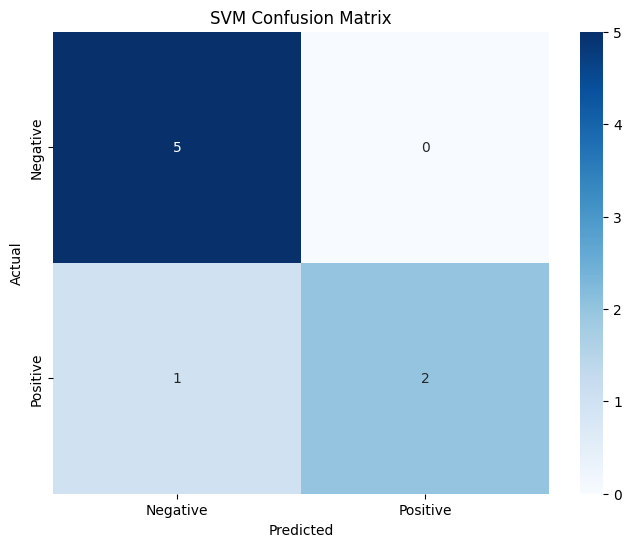

True Negatives: 5, False Positives: 0
False Negatives: 1, True Positives: 2

DETAILED BREAKDOWN OF PREDICTIONS

🔴 FALSE POSITIVES (0 samples):
Model incorrectly predicted these as POSITIVE when they were NEGATIVE:

🔴 FALSE NEGATIVES (1 samples):
Model incorrectly predicted these as NEGATIVE when they were POSITIVE:
  - 'Highly recommend this product'
    Actual: Positive | Predicted: Negative


✅ TRUE POSITIVES (2 samples):
Model correctly predicted these as POSITIVE:
  - 'I love this product so much'
  - 'Game changer absolutely love it'

✅ TRUE NEGATIVES (5 samples):
Model correctly predicted these as NEGATIVE:
  - 'Quality was really bad'
  - 'Bad decision completely regret it'
  - 'I am very unhappy with this product'


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_bow)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

# ============ FIND SPECIFIC SAMPLES ============

# Identify indices for each category
true_negatives = np.where((y_test == 0) & (y_pred_bow == 0))[0]
false_positives = np.where((y_test == 0) & (y_pred_bow == 1))[0]
false_negatives = np.where((y_test == 1) & (y_pred_bow == 0))[0]
true_positives = np.where((y_test == 1) & (y_pred_bow == 1))[0]

print("\n" + "="*80)
print("DETAILED BREAKDOWN OF PREDICTIONS")
print("="*80)

# Show False Positives (Model predicted Positive, but actually Negative)
print(f"\n🔴 FALSE POSITIVES ({len(false_positives)} samples):")
print("Model incorrectly predicted these as POSITIVE when they were NEGATIVE:")
for idx in false_positives[:5]:  # Show first 5
    print(f"  - '{X_test[idx]}'")
    print(f"    Actual: Negative | Predicted: Positive\n")

# Show False Negatives (Model predicted Negative, but actually Positive)
print(f"\n🔴 FALSE NEGATIVES ({len(false_negatives)} samples):")
print("Model incorrectly predicted these as NEGATIVE when they were POSITIVE:")
for idx in false_negatives[:5]:  # Show first 5
    print(f"  - '{X_test[idx]}'")
    print(f"    Actual: Positive | Predicted: Negative\n")

# Show True Positives (Correctly predicted Positive)
print(f"\n✅ TRUE POSITIVES ({len(true_positives)} samples):")
print("Model correctly predicted these as POSITIVE:")
for idx in true_positives[:3]:  # Show first 3
    print(f"  - '{X_test[idx]}'")

# Show True Negatives (Correctly predicted Negative)
print(f"\n✅ TRUE NEGATIVES ({len(true_negatives)} samples):")
print("Model correctly predicted these as NEGATIVE:")
for idx in true_negatives[:3]:  # Show first 3
    print(f"  - '{X_test[idx]}'")


In [13]:
def predict_sentiment(text, show_all_models=True):
    """
    Predict sentiment using all trained models.
    """
    print(f"\nReview: '{text}'")
    print("="*80)

    # SVM with BoW
    text_bow = bow_vectorizer.transform([text])
    pred_bow = svm_bow.predict(text_bow)[0]
    print(f"SVM (BoW):        {'Positive' if pred_bow == 1 else 'Negative'}")

In [14]:
# Enter your custom review here
custom_review = "The food was bad. I ordered shawarma and tandoori, shawarma was filled with bones and tandoori had a foul smell."

# Predict sentiment using the defined function
# show_all_models is set to False to skip OpenAI calls if not configured or rate-limited
predict_sentiment(custom_review, show_all_models=False)


Review: 'The food was bad. I ordered shawarma and tandoori, shawarma was filled with bones and tandoori had a foul smell.'
SVM (BoW):        Negative


TF-IDF Feature matrix shape: (30, 23)
Number of unique features: 23

Top 20 TF-IDF features (words):
['absolutely' 'amazing' 'did' 'enemy' 'enemy gift' 'experience'
 'fantastic' 'garbage' 'gift' 'good' 'great' 'horrible' 'impressed' 'life'
 'money' 'oh' 'product' 'quality' 'really' 'really impressed']

SVM (TF-IDF) Accuracy: 0.6250

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.80      0.73         5
    Positive       0.50      0.33      0.40         3

    accuracy                           0.62         8
   macro avg       0.58      0.57      0.56         8
weighted avg       0.60      0.62      0.60         8



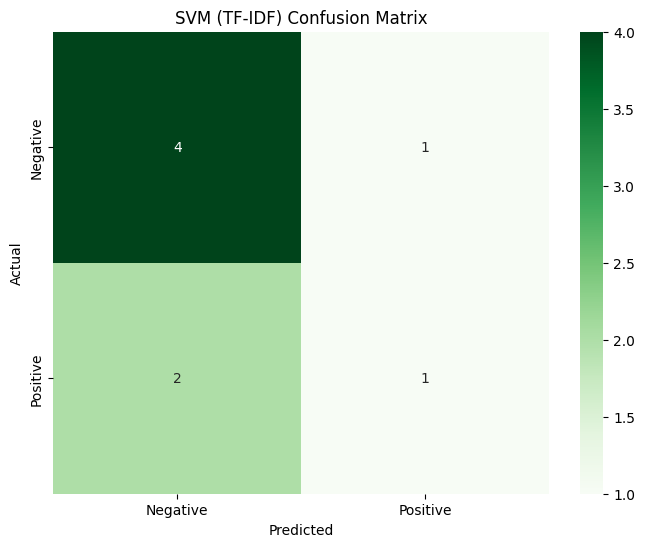


True Negatives: 4, False Positives: 1
False Negatives: 2, True Positives: 1

COMPARISON: BoW vs TF-IDF
BoW Accuracy:    0.8750
TF-IDF Accuracy: 0.6250
Difference:      0.2500


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create TF-IDF vectorizer
# TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization:
# This technique converts text to numerical features, giving more weight to
# important words and less weight to common words.
# TF (Term Frequency): How often a word appears in a document
# IDF (Inverse Document Frequency): How rare/important a word is across all documents
# max_features=100: Limits vocabulary to 100 most important features
# stop_words='english': Removes common English words that don't carry sentiment
# ngram_range=(1, 2): Includes both single words and word pairs
# min_df=2: Ignores words that appear in fewer than 2 documents
# max_df=0.8: Ignores words that appear in more than 80% of documents
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

# Transform text to TF-IDF feature vectors
# fit_transform(): Learns vocabulary from training data and converts to TF-IDF vectors
# transform(): Uses learned vocabulary to convert test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Feature matrix shape: {X_train_tfidf.shape}")
print(f"Number of unique features: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"\nTop 100 TF-IDF features (words):")
print(tfidf_vectorizer.get_feature_names_out()[:100])

# Train SVM with TF-IDF
# SVM (Support Vector Machine) Model Creation:
# SVC creates a classifier that finds the optimal boundary between sentiments
# kernel='linear': Uses linear decision boundary (works well for text)
# random_state=42: Ensures reproducible results
svm_tfidf = SVC(kernel='linear', random_state=42)

# Model Training:
# fit() trains the SVM on TF-IDF vectors and their sentiment labels
# The model learns which TF-IDF patterns indicate positive vs negative sentiment
svm_tfidf.fit(X_train_tfidf, y_train)

# Evaluate the model
# predict(): Uses trained model to predict sentiments for test data
y_pred_tfidf = svm_tfidf.predict(X_test_tfidf)

# Accuracy Calculation:
# Compares predictions with actual labels to measure performance
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f"\nSVM (TF-IDF) Accuracy: {accuracy_tfidf:.4f}")

# Classification Report:
# Shows precision, recall, F1-score for each sentiment class
# Precision: Of predicted positives/negatives, how many were correct?
# Recall: Of actual positives/negatives, how many did we find?
# F1-score: Balanced measure combining precision and recall
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=['Negative', 'Positive']))

# Generate confusion matrix
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM (TF-IDF) Confusion Matrix')
plt.show()

print(f"\nTrue Negatives: {cm_tfidf[0,0]}, False Positives: {cm_tfidf[0,1]}")
print(f"False Negatives: {cm_tfidf[1,0]}, True Positives: {cm_tfidf[1,1]}")

# Compare BoW vs TF-IDF
print("\n" + "="*80)
print("COMPARISON: BoW vs TF-IDF")
print("="*80)
print(f"BoW Accuracy:    {accuracy_bow:.4f}")
print(f"TF-IDF Accuracy: {accuracy_tfidf:.4f}")
print(f"Difference:      {abs(accuracy_tfidf - accuracy_bow):.4f}")
